- Grafos en Network X
- Análisis en PuLP

#### TODOS
- [X] Datos
  
- [ ] 2.1. Flujo al costo mínimo -> Cantidad: 600, Mínimo 20% debe llegar al destino 80

- [ ] 2.2. Flujo máximo

- [ ] 2.3.Ruta más corta -> Indicar cual es la ruta más corta entre 1 o 2 (origenes) a 78, 79,80 (destinos)

- [ ] 3. Análisis de sensibilidad y modificación para encontrar mejores soluciones

- [ ] Hacer un cambio en cada modelo y justificarlo con base en el análisis de sensibilidad


In [1]:
import pandas as pd
import numpy as np

In [2]:
url = "https://raw.githubusercontent.com/Samu-Kiss/UNI-26-10-Proyecto-Optimizacion/refs/heads/main/matriz_de_datos2.csv"
df = pd.read_csv(url)
df.head()

,Origen,Destino,Costo,Distancia,Capacidad
0,1,37,45,121,150
1,1,29,50,43,150
2,1,75,42,178,150
3,1,18,48,86,150
4,1,4,55,44,150


# Visualización del Grafo

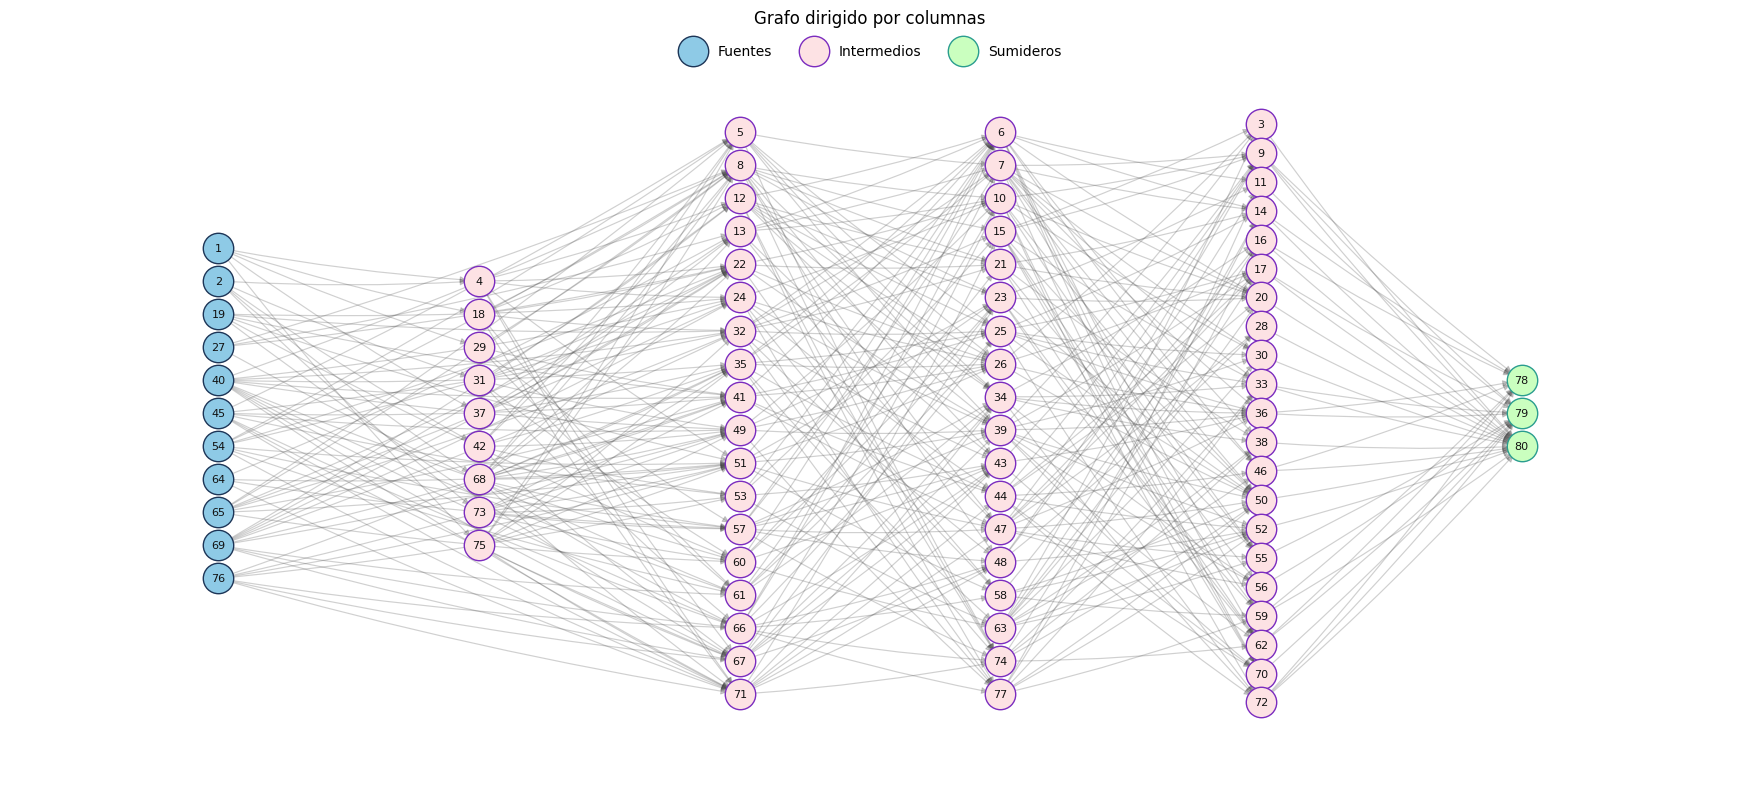

In [22]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import networkx as nx
from collections import defaultdict, deque

# Limpia nombres de columnas para evitar espacios en el encabezado del CSV.
df.columns = df.columns.str.strip()

# Convierte columnas relevantes a numericas por seguridad.
for col in ["Origen", "Destino", "Costo", "Distancia", "Capacidad"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["Origen", "Destino"])
df[["Origen", "Destino"]] = df[["Origen", "Destino"]].astype(int)

# Crea un grafo dirigido a partir de las columnas Origen y Destino.
G = nx.from_pandas_edgelist(
    df,
    source="Origen",
    target="Destino",
    edge_attr=["Costo", "Distancia", "Capacidad"],
    create_using=nx.DiGraph(),
)

nodes = sorted(G.nodes())
fuentes = sorted([n for n in nodes if G.in_degree(n) == 0])
sumideros = sorted([n for n in nodes if G.out_degree(n) == 0])

# Respaldo para casos no estandar (por ejemplo, grafos con ciclos sin fuente/sumidero claro).
if not fuentes and nodes:
    fuentes = [nodes[0]]
if not sumideros and nodes:
    sumideros = [nodes[-1]]

set_fuentes = set(fuentes)
set_sumideros = set(sumideros)
intermedios = [n for n in nodes if n not in set_fuentes and n not in set_sumideros]

# Nivel inicial por distancia minima desde fuentes.
niveles = {n: 0 for n in fuentes}
cola = deque(fuentes)
while cola:
    u = cola.popleft()
    for v in G.successors(u):
        nuevo_nivel = niveles[u] + 1
        if v not in niveles or nuevo_nivel < niveles[v]:
            niveles[v] = nuevo_nivel
            cola.append(v)

# Asignacion inicial de columnas.
columna_nodo = {}
for n in fuentes:
    columna_nodo[n] = 0
for n in intermedios:
    columna_nodo[n] = max(1, niveles.get(n, 1))

max_col_intermedio = max((columna_nodo[n] for n in intermedios), default=0)
col_sumidero = max_col_intermedio + 1
for n in sumideros:
    columna_nodo[n] = col_sumidero

# Regla pedida: si hay arco entre dos nodos, no pueden quedar en la misma columna.
max_iter = max(1, len(nodes) * len(nodes))
for _ in range(max_iter):
    changed = False
    for u, v in G.edges():
        if columna_nodo[u] == columna_nodo[v]:
            if v in set_sumideros:
                col_sumidero += 1
                for s in sumideros:
                    columna_nodo[s] = col_sumidero
            elif v in set_fuentes:
                if u not in set_fuentes and columna_nodo[u] > 0:
                    columna_nodo[u] -= 1
                else:
                    columna_nodo[v] += 1
            else:
                columna_nodo[v] += 1
            changed = True
    if not changed:
        break

# Compacta indices de columnas sin alterar el orden izquierda->derecha.
columnas_unicas = sorted(set(columna_nodo.values()))
remap_col = {c: i for i, c in enumerate(columnas_unicas)}
columna_nodo = {n: remap_col[c] for n, c in columna_nodo.items()}
col_sumidero = max((columna_nodo[s] for s in sumideros), default=0)

columnas = defaultdict(list)
for n, c in columna_nodo.items():
    columnas[c].append(n)


def y_positions(n, sep=1.0):
    if n == 1:
        return [0.0]
    centro = (n - 1) / 2
    return [(centro - i) * sep for i in range(n)]


# Reordena nodos dentro de cada columna para reducir cruces de aristas.
orden_col = {c: sorted(v, reverse=True) for c, v in columnas.items()}
columnas_ordenadas = sorted(orden_col.keys())
node_to_col = dict(columna_nodo)

for _ in range(5):
    pos_y = {}
    for c in columnas_ordenadas:
        for n, y in zip(orden_col[c], y_positions(len(orden_col[c]), sep=1.0)):
            pos_y[n] = y

    for c in columnas_ordenadas[1:]:
        def key_izq(nodo):
            vecinos = [
                pos_y[p]
                for p in G.predecessors(nodo)
                if node_to_col.get(p, c) < c and p in pos_y
            ]
            return sum(vecinos) / len(vecinos) if vecinos else pos_y.get(nodo, 0.0)

        orden_col[c] = sorted(orden_col[c], key=key_izq)

    pos_y = {}
    for c in columnas_ordenadas:
        for n, y in zip(orden_col[c], y_positions(len(orden_col[c]), sep=1.0)):
            pos_y[n] = y

    for c in reversed(columnas_ordenadas[:-1]):
        def key_der(nodo):
            vecinos = [
                pos_y[s]
                for s in G.successors(nodo)
                if node_to_col.get(s, c) > c and s in pos_y
            ]
            return sum(vecinos) / len(vecinos) if vecinos else pos_y.get(nodo, 0.0)

        orden_col[c] = sorted(orden_col[c], key=key_der)

# Orden final dentro de cada columna: de mayor a menor.
for c in columnas_ordenadas:
    orden_col[c] = sorted(orden_col[c], reverse=False)


# Alto maximo por columna = 14 unidades.
max_col_height = 14.0


def y_positions_limited(n, max_height=14.0, pref_sep=0.8):
    if n <= 1:
        return [0.0]
    sep = min(pref_sep, max_height / (n - 1))
    return [((n - 1) / 2 - i) * sep for i in range(n)]


x_sep = 2.8
pos = {}
for c in columnas_ordenadas:
    nodos_col = orden_col[c]
    ys = y_positions_limited(len(nodos_col), max_height=max_col_height, pref_sep=0.8)
    for nodo, y in zip(nodos_col, ys):
        pos[nodo] = (c * x_sep, y)

# Garantiza posicion de todos los nodos.
for n in nodes:
    if n not in pos:
        pos[n] = (x_sep, 0.0)

max_nodes_col = max((len(v) for v in columnas.values()), default=1)
node_size = int(max(170, min(480, 15000 / max_nodes_col)))
label_font = 7 if max_nodes_col >= 22 else 8

fig_w = max(15, (len(columnas_ordenadas) + 1) * 2.5)
fig_h = max(7, min(10, 4.8 + max_col_height * 0.24))

plt.figure(figsize=(fig_w, fig_h))

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=fuentes,
    node_size=node_size,
    node_color="#8ecae6",
    edgecolors="#1d3557",
    linewidths=1.0,
    label="Fuentes",
)

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=intermedios,
    node_size=node_size,
    node_color="#fde2e4",
    edgecolors="#7b2cbf",
    linewidths=1.0,
    label="Intermedios",
)

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=sumideros,
    node_size=node_size,
    node_color="#caffbf",
    edgecolors="#2a9d8f",
    linewidths=1.0,
    label="Sumideros",
)

nx.draw_networkx_edges(
    G,
    pos,
    arrows=True,
    arrowstyle="-|>",
    arrowsize=10,
    width=0.85,
    alpha=0.25,
    edge_color="#444444",
    connectionstyle="arc3,rad=0.03",
)

text_items = nx.draw_networkx_labels(
    G,
    pos,
    font_size=label_font,
    font_color="#111111",
)


y_top = max((p[1] for p in pos.values()), default=0) + 1.2

plt.title("Grafo dirigido por columnas")
plt.axis("off")
plt.legend(loc="upper center", ncol=3, frameon=False)
plt.margins(0.10)
plt.tight_layout()
plt.show()